# Question 1 — Indeterminate Beam (DSM by Hand)
---

## 1. Node and Unit Information

### 1.1 Node coordinates
- Node 1: $x_1=0$
- Node 2: $x_2=4\ \text{m}$
- Node 3: $x_3=7\ \text{m}$
- Node 4: $x_4=11\ \text{m}$

### 1.2 Global DOFs

- Node 1: DOF1 $u_{1y}$, DOF2 $\theta_1$
- Node 2: DOF3 $u_{2y}$, DOF4 $\theta_2$
- Node 3: DOF5 $u_{3y}$, DOF6 $\theta_3$
- Node 4: DOF7 $u_{4y}$, DOF8 $\theta_4$

### 1.3 Unit Setup

- Element 1: $(1\text{-}2)$, $L_1=4\ \text{m}$
- Element 2: $(2\text{-}3)$, $L_2=3\ \text{m}$
- Element 3: $(3\text{-}4)$, $L_3=4\ \text{m}$

### 1.4 Restrained and Free DOFs

- Node 1 Fixed, $u_{1y}=0,\ \theta_1=0$
- Node 2 x-roller, $u_{2y}=0,\ \theta_2 \quad \text{free}$
- Node 3 x-roller, $u_{3y}=0,\ \theta_3 \quad \text{free}$
- Node 4 Fixed, $u_{4y}=0,\ \theta_4=0$

Free DOFs:
$$
\boldsymbol{u}_f=\{\theta_2,\ \theta_3\}=\{u_4, u_6\}
$$

Restrained DOFs:
$$
\boldsymbol{u}_r=\{u_{1y}, \theta_1, u_{2y}, u_{3y}, u_{4y}, \theta_4\}=\{u_1, u_2, u_3, u_5, u_7, u_8\}
$$

### 1.5 Unit load

- Element 1: Point load at midpoint $P=150\ \text{kN}$
- Element 3: Distributed load throughout full span $q=37.5\ \text{kN/m}$

---

## 2. Materials info

- $E=200\ \text{GPa}$
- $I=108 \times 10^{6}\ \text{mm}^4= 1.08\times 10^{-4}\ \text{m}^4$

Therefore:
$$
EI = (200\times 10^9)(1.08\times 10^{-4})
=2.16\times 10^7\ \text{Nm}^2
=21600\ \text{kNm}^2
$$

---

## 3. Beam Element Stiffness Matrix $\boldsymbol{k}^{(e)}$

4×4 Beam Element Stiffness Matrix:
$$
\boldsymbol{k}'=\frac{EI}{L^3}
\begin{bmatrix}
12 & 6L & -12 & 6L\\
6L & 4L^2 & -6L & 2L^2\\
-12 & -6L & 12 & -6L\\
6L & 2L^2 & -6L & 4L^2
\end{bmatrix}
$$

### 3.1 For Element 1 and 3, ($L=4\ \text{m}$)

$$
\frac{EI}{L^3}=\frac{21600}{4^3}=\frac{21600}{64}=337.5
$$

$$
\boldsymbol{k}_{(1, 3)}=
\begin{bmatrix}
4050 & 8100 & -4050 & 8100\\
8100 & 21600 & -8100 & 10800\\
-4050 & -8100 & 4050 & -8100\\
8100 & 10800 & -8100 & 21600
\end{bmatrix}
$$

### 3.2 For Element 2, ($L=3\ \text{m}$)

$$
\frac{EI}{L^3}=\frac{21600}{3^3}=\frac{21600}{27}=800
$$

$$
\boldsymbol{k}_{(2)}=
\begin{bmatrix}
9600 & 14400 & -9600 & 14400\\
14400 & 28800 & -14400 & 14400\\
-9600 & -14400 & 9600 & -14400\\
14400 & 14400 & -14400 & 28800
\end{bmatrix}
$$

---

## 4. Assemble global stiffness matrix $\boldsymbol{K}$

- Element 1 $\Rightarrow$ DOF [1,2,3,4] with $\boldsymbol{k}^{(1)}$
- Element 2 $\Rightarrow$ DOF [3,4,5,6] with $\boldsymbol{k}^{(2)}$
- Element 3 $\Rightarrow$ DOF [5,6,7,8] with $\boldsymbol{k}^{(3)}$

Therefore: 

$$
\boldsymbol{K}=
\begin{bmatrix}
4050&8100&-4050&8100&0&0&0&0\\
8100&21600&-8100&10800&0&0&0&0\\
-4050&-8100&4050+9600&14400-8100&-9600&14400&0&0\\
8100&10800&-8100+14400&28800+21600&-14400&14400&0&0\\
0&0&-9600&-14400&4050+9600&8100-14400&-4050&8100\\
0&0&14400&14400&8100-14400&28800+21600&-8100&10800\\
0&0&0&0&-4050&-8100&4050&-8100\\
0&0&0&0&8100&10800&-8100&21600
\end{bmatrix}
$$

$$
=\begin{bmatrix}
4050&8100&-4050&8100&0&0&0&0\\
8100&21600&-8100&10800&0&0&0&0\\
-4050&-8100&13650&6300&-9600&14400&0&0\\
8100&10800&6300&50400&-14400&14400&0&0\\
0&0&-9600&-14400&13650&-6300&-4050&8100\\
0&0&14400&14400&-6300&50400&-8100&10800\\
0&0&0&0&-4050&-8100&4050&-8100\\
0&0&0&0&8100&10800&-8100&21600
\end{bmatrix}
$$

---

## 5. FEFs and $\boldsymbol{F}^F$

### 5.1 Element 1

Point load at midspan:

$$
F_1=F_2=\frac{P}{2}=75\ \text{kN}
$$
$$
M_1=+\frac{PL}{8}=75\ \text{kNm},\qquad
M_2=-\frac{PL}{8}=-75\ \text{kNm}
$$

$$
\boldsymbol{Q}^{F}_{(1)}=
\begin{bmatrix}
75\\
75\\
75\\
-75
\end{bmatrix}
$$

### 5.2 Element 3

Distributed load throughout the span:
$$
F_3=F_4=\frac{qL}{2}=75\ \text{kN}
$$
$$
M_3=+\frac{qL^2}{12}=50\ \text{kNm},\qquad
M_4=-\frac{qL^2}{12}=-50\ \text{kNm}
$$

$$
\boldsymbol{Q}^{F}_{(3)}=
\begin{bmatrix}
75\\
50\\
75\\
-50
\end{bmatrix}
$$


### 5.3 Scatter-add FEFs into $\boldsymbol{F}^F$

$$
\boldsymbol{Q}^{F}_{(1)}=
\begin{bmatrix}
75\\
75\\
75\\
-75
\end{bmatrix}
\quad\Rightarrow\quad
\begin{bmatrix}
1\\
2\\
3\\
4
\end{bmatrix}
$$

$$
\boldsymbol{Q}^{F}_{(3)}=
\begin{bmatrix}
75\\
50\\
75\\
-50
\end{bmatrix}
\quad\Rightarrow\quad
\begin{bmatrix}
5\\
6\\
7\\
8
\end{bmatrix}
$$

$$
\boldsymbol{F}^F=
\begin{bmatrix}
75\\
75\\
75\\
-75\\
75\\
50\\
75\\
-50
\end{bmatrix}
$$

---

## 6. Partition DOFs into free and restrained

$$
\left[
\begin{array}{cc|cccccc}
50400 & 14400 & 8100 & 10800 & 6300 & -14400 & 0 & 0\\
14400 & 50400 & 0 & 0 & 14400 & -6300 & -8100 & 10800\\ \hline
8100 & 0 & 4050 & 8100 & -4050 & 0 & 0 & 0\\
10800 & 0 & 8100 & 21600 & -8100 & 0 & 0 & 0\\
6300 & 14400 & -4050 & -8100 & 13650 & -9600 & 0 & 0\\
-14400 & -6300 & 0 & 0 & -9600 & 13650 & -4050 & 8100\\
0 & -8100 & 0 & 0 & 0 & -4050 & 4050 & -8100\\
0 & 10800 & 0 & 0 & 0 & 8100 & -8100 & 21600
\end{array}
\right]
\left\{
\begin{array}{c}
\theta_2\\
\theta_3\\ \hline
0\\
0\\
0\\
0\\
0\\
0
\end{array}
\right\}=
\left\{
\begin{array}{c}
0\\
0\\ \hline
F_1\\
M_1\\
F_2\\
F_3\\
F_4\\
M_4
\end{array}
\right\}-
\left\{
\begin{array}{c}
-75\\
50\\ \hline
75\\
75\\
75\\
75\\
75\\
-50
\end{array}
\right\}
$$

---

## 7. Solve for unknown displacements $\{\theta_2,\theta_3\}$

The solution for the unknown displacements at the free DOFs:

$$
\boldsymbol{u_f} = \boldsymbol{K}_{ff}^{-1}\left(\boldsymbol{F}_f - \boldsymbol{F}_f^{F} - \boldsymbol{K}_{fr}\boldsymbol{u}_r\right)
$$

where

$$
\boldsymbol{F}=\boldsymbol{0} \qquad \boldsymbol{u}_r=\boldsymbol{0}
$$

Therefore
$$
\boldsymbol{K}_{ff}\boldsymbol{u}_f=\boldsymbol{F}_f-\boldsymbol{F}_f^F = -\boldsymbol{F}_f^F
$$

Given
$$
\boldsymbol{K}_{ff}=
\begin{bmatrix}
50400 & 14400\\
14400 & 50400
\end{bmatrix},\qquad
\boldsymbol{F}_f^F=
\begin{bmatrix}
-75\\
50
\end{bmatrix}
$$

Therefore:

$$
\begin{bmatrix}
\theta_2\\
\theta_3
\end{bmatrix}=
\begin{bmatrix}
\frac{7}{324000} & -\frac{1}{162000}\\[3pt]
-\frac{1}{162000} & \frac{7}{324000}
\end{bmatrix}
\begin{bmatrix}
-75\\
50
\end{bmatrix}=
\begin{bmatrix}
0.00192901\\
-0.00154321
\end{bmatrix}\ \text{rad}
$$

---

## 8. Recover support reactions

The solution for the unknown reactions at the restrained DOFs:
$$
\boldsymbol{F}_r = \boldsymbol{K}_{rf}\boldsymbol{u}_f + \boldsymbol{K}_{rr}\boldsymbol{u}_r +\boldsymbol{F}_r^F
$$

where

$$
\boldsymbol{u}_r=\boldsymbol{0}
$$

$$
\begin{bmatrix}
F_1\\
M_1\\
F_2\\
F_3\\
F_4\\
M_4
\end{bmatrix}=
\begin{bmatrix}
8100 & 0 \\
10800 & 0\\
6300 & 14400\\
-14400 & -6300\\
0 & -8100\\
0 & 10800
\end{bmatrix}
\begin{bmatrix}
0.00192901\\
-0.00154321
\end{bmatrix}+
\begin{bmatrix}
75\\
75\\
75\\
75\\
75\\
-50
\end{bmatrix}=
\begin{bmatrix}
90.624981\\
95.833308\\
64.930539\\
56.944479\\
87.500001\\
-66.666668
\end{bmatrix}
$$

Therefore:

- **Node 1 (Fixed) **
  - Vertical reaction: $F_1=90.625\ \text{kN}$
  - Bending moment: $M_1=95.833\ \text{kNm}$

- **Node 2 (x-roller) **
  - Vertical reaction: $F_2=64.931\ \text{kN}$

- **Node 3 (x-roller) **
  - Vertical reaction: $F_3=56.944\ \text{kN}$

- **Node 4 (Fixed) **
  - Vertical reaction: $F_4=87.5\ \text{kN}$
  - Bending moment: $M_4=-66.667\ \text{kNm}$

---

## 9. Global Equilibrium Check

### 9.1 Vertical Force Equilibrium
Total external load: 
$$
150 + 37.5\times 4 = 150 + 150 = 300\ \text{kN}
$$

Total reactions: 
$$
R_{1y}+R_{2y}+R_{3y}+R_{4y}
=90.625+64.931+56.944+87.5
=300\ \text{kN}
$$

Sanity Check:
$$
300-300 =0
$$

### 9.2 Moment Equilibrium (Take Node 1 as the geometric center) 

Total external load moment: 
- Point load:
$$-150\times 2=-300 \text{kNm}$$
- Distributed load:
$$-150\times9 =-1350 \text{kNm}$$

Total reactions: 
$$
M_1 + 4 \times F_2 + 7 \times F_3 + 11 \times F_4 + M_4=
95.833 + 4 \times 64.931+ 7 \times 56.944 + 11 \times 87.5 - 66.667=
1649.998 \text{kNm}
$$

Sanity Check:
$$
1649.998-1650 =-0.002 \text{kNm}
$$

---

## 10. Element Global Displacement Vectors

### 10.1 Element 1

$$
\boldsymbol{u}_{(1)}=
\begin{bmatrix}
0\\
0\\
0\\
0.00192901
\end{bmatrix}
$$

### 10.2 Element 2

$$
\boldsymbol{u}_{(2)}=
\begin{bmatrix}
0\\
0.00192901\\
0\\
-0.00154321
\end{bmatrix}
$$

### 10.3 Element 3

$$
\boldsymbol{u}_{(3)}=
\begin{bmatrix}
0\\
-0.00154321\\
0\\
0
\end{bmatrix}
$$

---

## 11. Element FEF vectors

### 11.1 Element 1

$$
\boldsymbol{f}^{(1)}=\boldsymbol{k}^{(1)}\boldsymbol{u}^{(1)}+\boldsymbol{Q}^{F(1)}=
\begin{bmatrix}
90.625\\
95.833\\
59.375\\
-33.333
\end{bmatrix}
$$

### 11.2 Element 2

$$
\boldsymbol{f}^{(2)}=\boldsymbol{k}^{(2)}\boldsymbol{u}^{(2)}+\boldsymbol{0}=
\begin{bmatrix}
5.556\\
33.333\\
-5.556\\
-16.667
\end{bmatrix}
$$

### 11.3 Element 3

$$
\boldsymbol{f}^{(3)}=\boldsymbol{k}^{(3)}\boldsymbol{u}^{(3)}+\boldsymbol{Q}^{F(3)}=
\begin{bmatrix}
62.5\\
16.667\\
87.5\\
-66.667
\end{bmatrix}
$$

---

## 12. Deformed Shape


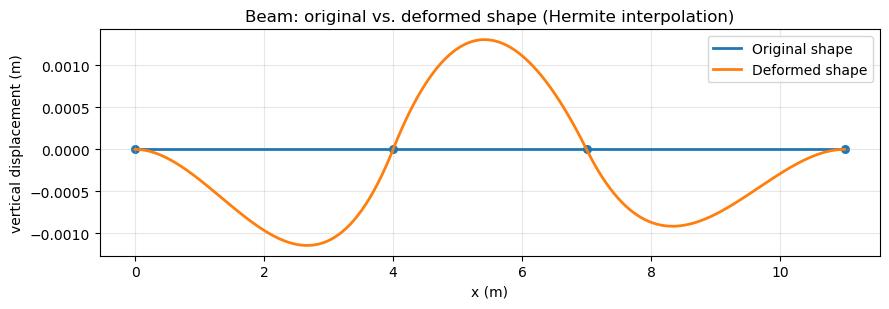

Max actual |w(x)| = 1.306077e-03 m


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Beam geometry (m)
# -----------------------------
x_nodes = np.array([0.0, 4.0, 7.0, 11.0])

# Nodal DOFs per node: [v, theta]
# Given: v1=v2=v3=v4=0, theta1=theta4=0, theta2/theta3 from your solution
v = np.array([0.0, 0.0, 0.0, 0.0])  # vertical displacements (m)
theta = np.array([0.0, 0.00192901, -0.00154321, 0.0])  # rotations (rad)

# -----------------------------
# Cubic Hermite beam interpolation (Euler-Bernoulli)
# w(x) = N1*v1 + N2*theta1 + N3*v2 + N4*theta2
# with s = xi/L in [0,1], and N2,N4 include factor L
# -----------------------------
def hermite_w(xi, L, v1, th1, v2, th2):
    s = xi / L
    N1 = 1 - 3*s**2 + 2*s**3
    N2 = L*(s - 2*s**2 + s**3)
    N3 = 3*s**2 - 2*s**3
    N4 = L*(-s**2 + s**3)
    return N1*v1 + N2*th1 + N3*v2 + N4*th2

# Build deformed shape along entire beam
xs_all, ws_all = [], []
n_per_elem = 200

for e in range(3):
    x1, x2 = x_nodes[e], x_nodes[e+1]
    L = x2 - x1
    xi = np.linspace(0.0, L, n_per_elem)
    x_global = x1 + xi

    w = hermite_w(xi, L, v[e], theta[e], v[e+1], theta[e+1])

    xs_all.append(x_global)
    ws_all.append(w)

x_plot = np.concatenate(xs_all)
w_plot = np.concatenate(ws_all)

# -----------------------------
# Scale for visibility (auto)
# -----------------------------
w_max = np.max(np.abs(w_plot))
scale = 1.0
# -----------------------------
# Plot original and deformed shapes
# -----------------------------
plt.figure(figsize=(9, 3.2))
plt.plot(x_plot, np.zeros_like(x_plot), linewidth=2, label="Original shape")
plt.plot(x_plot, scale*w_plot, linewidth=2, label=f"Deformed shape")

plt.scatter(x_nodes, np.zeros_like(x_nodes), s=30)
plt.xlabel("x (m)")
plt.ylabel("vertical displacement (m)")
plt.title("Beam: original vs. deformed shape (Hermite interpolation)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Max actual |w(x)| = {w_max:.6e} m")

# Question 2 — Indeterminate Frame (DSM by Hand)

## 1. Define the structure

### 1.1 Node coordinates

- Node 1: $x_1=0 \quad y_1=0$
- Node 2: $x_2=0 \quad y_2=10\ \text{m}$
- Node 3: $x_3=8 \text{m} \quad y_3=10\ \text{m}$

### 1.2 Global DOFs

- Node 1: DOF1 $u_{1x}$, DOF2 $u_{1y}$, DOF3 $\theta_1$
- Node 2: DOF4 $u_{2x}$, DOF5 $u_{2y}$, DOF6 $\theta_2$
- Node 3: DOF7 $u_{3x}$, DOF8 $u_{3y}$, DOF9 $\theta_3$

### 1.3 Unit Setup

- Element 1: $(1\text{-}2)$, $L_1=4\ \text{m}$
- Element 2: $(2\text{-}3)$, $L_2=3\ \text{m}$


### 1.4 Restrained and Free DOFs

- Node 1 Fixed, $u_{1x}=u_{1y}=\theta_1=0$
- Node 3 Pin, $u_{3x}=u_{3y}=0,\ \theta_3 \quad \text{free}$

Free DOFs:
$$
\{\boldsymbol{u}_f\}=\{u_{2x},u_{2y},\theta_2,\theta_3\}=\{u_4,u_5,u_6,u_9\}
$$

Restrained DOFs:
$$
\{\boldsymbol{u}_r\}=\{u_{1x},u_{1y},\theta_1,u_{3x},u_{3y}\}=\{u_1,u_2,u_3,u_7,u_8\}
$$

### 1.5 Unit load

- Element 1: Distributed load throughout full span $q=24\ \text{kN/m}$
- Element 2: Point load at midpoint $P=75\ \text{kN}$

---

## 2. Materials info

- $E=200\ \text{GPa}$
- $A=4740\ \text{mm}^2=4.74 \times 10^{-3}\ \text{m}^2$
- $I=22.2\times 10^6\ \text{mm}^4=2.22\times 10^{-5}\ \text{m}^4$

Therefore:
$$
EA=(2.00\times 10^8)(4.74 \times 10^{-3})=9.48\times 10^5\ \text{kN}
$$
$$
EI=(2.00\times 10^8)(2.22\times 10^{-5})=4440\ \text{kN}\cdot\text{m}^2
$$

---

## 3. Beam Element Stiffness Matrix $\boldsymbol{k}^{(e)}$

2D Frame Stiffness Matrix:
$$
\boldsymbol{k}'=
\begin{bmatrix}
\frac{EA}{L} & 0 & 0 & -\frac{EA}{L} & 0 & 0 \\[2pt]
0 & \frac{12EI}{L^3} & \frac{6EI}{L^2} & 0 & -\frac{12EI}{L^3} & \frac{6EI}{L^2} \\[2pt]
0 & \frac{6EI}{L^2} & \frac{4EI}{L} & 0 & -\frac{6EI}{L^2} & \frac{2EI}{L} \\[2pt]
-\frac{EA}{L} & 0 & 0 & \frac{EA}{L} & 0 & 0 \\[2pt]
0 & -\frac{12EI}{L^3} & -\frac{6EI}{L^2} & 0 & \frac{12EI}{L^3} & -\frac{6EI}{L^2} \\[2pt]
0 & \frac{6EI}{L^2} & \frac{2EI}{L} & 0 & -\frac{6EI}{L^2} & \frac{4EI}{L}
\end{bmatrix}
$$

### 3.1 Element 1, ($L=10\ \text{m}$)
$$
\frac{EA}{L}= \frac{9.48\times 10^5}{10}=94800
$$
$$
\frac{12EI}{L^3}= \frac{12\times 4440}{10^3}=53.28
$$
$$
\frac{6EI}{L^2}= \frac{6\times 4440}{10^2}=266.4
$$
$$
\frac{4EI}{L}= \frac{4\times 4440}{10}=1776
$$
$$
\frac{2EI}{L}=888
$$

Therefore:
$$
\boldsymbol{k}_{(1)}=
\begin{bmatrix}
94800 & 0 & 0 & -94800 & 0 & 0\\
0 & 53.28 & 266.4 & 0 & -53.28 & 266.4\\
0 & 266.4 & 1776 & 0 & -266.4 & 888\\
-94800 & 0 & 0 & 94800 & 0 & 0\\
0 & -53.28 & -266.4 & 0 & 53.28 & -266.4\\
0 & 266.4 & 888 & 0 & -266.4 & 1776
\end{bmatrix}
$$

### 3.2 Element 2, ($L=8\ \text{m}$)
$$
\frac{EA}{L}=\frac{9.48\times 10^5}{8}=118500
$$
$$
\frac{12EI}{L^3}= \frac{12\times 4440}{8^3}=104.0625
$$
$$
\frac{6EI}{L^2}= \frac{6\times 4440}{8^2}=416.25
$$
$$
\frac{4EI}{L}= \frac{4\times 4440}{8}=2220
$$
$$
\frac{2EI}{L}=1110
$$

Therefore:
$$
\boldsymbol{k}_{(2)}=
\begin{bmatrix}
118500 & 0 & 0 & -118500 & 0 & 0\\
0 & 104.0625 & 416.25 & 0 & -104.0625 & 416.25\\
0 & 416.25 & 2220 & 0 & -416.25 & 1110\\
-118500 & 0 & 0 & 118500 & 0 & 0\\
0 & -104.0625 & -416.25 & 0 & 104.0625 & -416.25\\
0 & 416.25 & 1110 & 0 & -416.25 & 2220
\end{bmatrix}
$$

---

## 4. Assemble global stiffness matrix $\boldsymbol{K}$

- Element 1 $\Rightarrow$ DOF [1,2,3,4,5,6] with $\boldsymbol{k}_{(1)}$
- Element 2 $\Rightarrow$ DOF [4,5,6,7,8,9] with $\boldsymbol{k}_{(2)}$

Therefore: 
$$
\boldsymbol{K}=
\begin{bmatrix}
53.28 & 0 & -266.4 & -53.28 & 0 & -266.4 & 0 & 0 & 0\\
0 & 94800 & 0 & 0 & -94800 & 0 & 0 & 0 & 0\\
-266.4 & 0 & 1776 & 266.4 & 0 & 888 & 0 & 0 & 0\\
-53.28 & 0 & 266.4 & 53.28 + 118500 & 0 & 266.4 & -118500 & 0 & 0\\
0 & -94800 & 0 & 0 & 94800 + 104.0625 & 416.25 & 0 & -104.0625 & 416.25\\
-266.4 & 0 & 888 & 266.4 & 416.25 & 1776 + 2220 & 0 & -416.25 & 1110\\
0 & 0 & 0 & -118500 & 0 & 0 & 118500 & 0 & 0\\
0 & 0 & 0 & 0 & -104.0625 & -416.25 & 0 & 104.0625 & -416.25\\
0 & 0 & 0 & 0 & 416.25 & 1110 & 0 & -416.25 & 2220
\end{bmatrix}
$$
$$
=\begin{bmatrix}
53.28 & 0 & -266.4 & -53.28 & 0 & -266.4 & 0 & 0 & 0\\
0 & 94800 & 0 & 0 & -94800 & 0 & 0 & 0 & 0\\
-266.4 & 0 & 1776 & 266.4 & 0 & 888 & 0 & 0 & 0\\
-53.28 & 0 & 266.4 & 118553.28 & 0 & 266.4 & -118500 & 0 & 0\\
0 & -94800 & 0 & 0 & 94904.0625 & 416.25 & 0 & -104.0625 & 416.25\\
-266.4 & 0 & 888 & 266.4 & 416.25 & 3996 & 0 & -416.25 & 1110\\
0 & 0 & 0 & -118500 & 0 & 0 & 118500 & 0 & 0\\
0 & 0 & 0 & 0 & -104.0625 & -416.25 & 0 & 104.0625 & -416.25\\
0 & 0 & 0 & 0 & 416.25 & 1110 & 0 & -416.25 & 2220
\end{bmatrix}
$$

---

## 5. Build transformation matrices and compute global element stiffness

Displacement transform:
$$
\boldsymbol{u}'=\boldsymbol{T}\boldsymbol{u}^{(e)},
\qquad
\boldsymbol{T}=
\begin{bmatrix}
\cos\theta & \sin\theta & 0 & 0 & 0 & 0\\
-\sin\theta & \cos\theta & 0 & 0 & 0 & 0\\
0 & 0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & \cos\theta & \sin\theta & 0\\
0 & 0 & 0 & -\sin\theta & \cos\theta & 0\\
0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
$$

Global element stiffness:
$$
\boldsymbol{k}=\boldsymbol{T}^T\boldsymbol{k}'\boldsymbol{T}
$$

### Element angles
- Element 1: $\theta=90^\circ \Rightarrow \cos\theta=0,\ \sin\theta=1$
- Element 2: $\theta=0^\circ \Rightarrow \text{Local coordinates are aligned with global coordinates}$
---

## 6 FEFs and $\boldsymbol{F}^F$

### 6.1 Element 1: uniform load $q_x=24$ kN/m to global $+x$

Distributed load throughout the span:
$$
F_1=F_2=\frac{qL}{2}=120\ \text{kN}
$$
$$
M_1=+\frac{qL^2}{12}=200\ \text{kNm},\qquad
M_2=-\frac{qL^2}{12}=-200\ \text{kNm}
$$

$$
\boldsymbol{Q}^{F}_{(1)}=
\begin{bmatrix}
0\\
120\\
200\\
0\\
120\\
-200
\end{bmatrix}
$$

Transform to global:
$$
\boldsymbol{F}^{F}_{(1)}=\boldsymbol{T}_1^T\boldsymbol{Q}^{F}_{(1)}=
\begin{bmatrix}
-120\\
0\\
200\\
-120\\
0\\
-200
\end{bmatrix}
$$

### 6.2 Element 2: midspan point load $P=75$ kN downward

Point load at midspan:
$$
F_2=F_3=\frac{P}{2}=37.5\ \text{kN}
$$
$$
M_2=+\frac{PL}{8}=75\ \text{kNm},\qquad
M_3=-\frac{PL}{8}=-75\ \text{kNm}
$$


Thus:
$$
\boldsymbol{Q}^{F}_{(2)}=
\begin{bmatrix}
0\\
37.5\\
75\\
0\\
37.5\\
-75
\end{bmatrix}
$$

Since local coordinates are aligned with global coordinates:
$$
\boldsymbol{F}^{F}_{(2)}=\boldsymbol{Q}^{F}_{(2)}
$$

### 6.3 Assemble the global $\boldsymbol{F}^F$ (size 9)
  
$$
\boldsymbol{F}^{F}_{(1)}=
\begin{bmatrix}
-120\\
0\\
200\\
-120\\
0\\
-200
\end{bmatrix}
\quad\Rightarrow\quad
\begin{bmatrix}
1\\
2\\
3\\
4\\
5\\
6
\end{bmatrix}
$$

$$
\boldsymbol{F}^{F}_{(2)}=
\begin{bmatrix}
0\\
37.5\\
75\\
0\\
37.5\\
-75
\end{bmatrix}
\quad\Rightarrow\quad
\begin{bmatrix}
4\\
5\\
6\\
7\\
8\\
9
\end{bmatrix}
$$

$$
\boldsymbol{F}^F=
\begin{bmatrix}
-120\\
0\\
200\\
-120\\
37.5\\
-125\\
0\\
37.5\\
-75
\end{bmatrix}
$$

---

## 7. Partition DOFs into free and restrained

$$
\left[
\begin{array}{cccc|ccccc}
118553.28 & 0 & 266.4 & 0 & -53.28 & 0 & 266.4 & -118500 & 0\\
0 & 94904.0625 & 416.25 & 416.25 & 0 & -94800 & 0 & 0 & -104.0625\\
266.4 & 416.25 & 3996 & 1110 & -266.4 & 0 & 888 & 0 & -416.25\\
0 & 416.25 & 1110 & 2220 & 0 & 0 & 0 & 0 & -416.25\\ \hline
-53.28 & 0 & -266.4 & 0 & 53.28 & 0 & -266.4 & 0 & 0\\
0 & -94800 & 0 & 0 & 0 & 94800 & 0 & 0 & 0\\
266.4 & 0 & 888 & 0 & -266.4 & 0 & 1776 & 0 & 0\\
-118500 & 0 & 0 & 0 & 0 & 0 & 0 & 118500 & 0\\
0 & -104.0625 & -416.25 & -416.25 & 0 & 0 & 0 & 0 & 104.0625
\end{array}
\right]
\left\{
\begin{array}{c}
u_{2x}\\
u_{2y}\\
\theta_2\\
\theta_3\\ \hline
0\\
0\\
0\\
0\\
0
\end{array}
\right\}=
\left\{
\begin{array}{c}
0\\
0\\
0\\
0\\ \hline
F_{1x}\\
F_{1y}\\
M_1\\
F_{3x}\\
F_{3y}
\end{array}
\right\}-
\left\{
\begin{array}{c}
-120\\
37.5\\
-125\\
-75\\ \hline
-120\\
0\\
200\\
0\\
37.5
\end{array}
\right\}
$$

---

## 8. Solve for unknown displacements

The solution for the unknown displacements at the free DOFs:

$$
\boldsymbol{u_f} = \boldsymbol{K}_{ff}^{-1}\left(\boldsymbol{F}_f - \boldsymbol{F}_f^{F} - \boldsymbol{K}_{fr}\boldsymbol{u}_r\right)
$$

where

$$
\boldsymbol{F}=\boldsymbol{0} \qquad \boldsymbol{u}_r=\boldsymbol{0}
$$

Therefore
$$
\boldsymbol{K}_{ff}\boldsymbol{u}_f=\boldsymbol{F}_f-\boldsymbol{F}_f^F = -\boldsymbol{F}_f^F
$$

Given
$$
\boldsymbol{K}_{ff}=
\begin{bmatrix}
118553.28 & 0 & 266.4 & 0\\
0 & 94904.0625 & 416.25 & 416.25\\
266.4 & 416.25 & 3996 & 1110\\
0 & 416.25 & 1110 & 2220
\end{bmatrix},
\qquad
\boldsymbol{F}_f^F=
\begin{bmatrix}
-120\\
37.5\\
-125\\
-75
\end{bmatrix}
$$

Therefore:
$$
\begin{bmatrix}
u_{2x}\\
u_{2y}\\
\theta_2\\
\theta_3
\end{bmatrix}=
\begin{bmatrix}
8.436\times 10^{-6} & 1.434\times 10^{-9} & -6.532\times 10^{-7} & 3.263\times 10^{-7}\\
1.434\times 10^{-9} & 1.055\times 10^{-5} & -6.380\times 10^{-7} & -1.659\times 10^{-6}\\
-6.532\times 10^{-7} & -6.380\times 10^{-7} & 2.907\times 10^{-4} & -1.452\times 10^{-4}\\
3.263\times 10^{-7} & -1.659\times 10^{-6} & -1.452\times 10^{-4} & 5.234\times 10^{-4}
\end{bmatrix}
\begin{bmatrix}
-120\\
37.5\\
-125\\
-75
\end{bmatrix}=
\begin{bmatrix}
0.00095515\\
-0.00059949\\
0.02539097\\
0.02120070
\end{bmatrix}
\left(
\begin{array}{c}
\text{m}\\
\text{m}\\
\text{rad}\\
\text{rad}
\end{array}
\right)
$$

---

## 9. Recover support reactions

The solution for the unknown reactions at the restrained DOFs:
$$
\boldsymbol{F}_r = \boldsymbol{K}_{rf}\boldsymbol{u}_f + \boldsymbol{K}_{rr}\boldsymbol{u}_r +\boldsymbol{F}_r^F
$$

where

$$
\boldsymbol{u}_r=\boldsymbol{0}
$$

Result (restrained DOFs $[1,2,3,7,8]$):
$$
\begin{bmatrix}
F_{1x}\\
F_{1y}\\
M_1\\
F_{3x}\\
F_{3y}
\end{bmatrix}=
\begin{bmatrix}
-53.28 & 0 & -266.4 & 0\\
0 & -94800 & 0 & 0\\
266.4 & 0 & 888 & 0\\
-118500 & 0 & 0 & 0\\
0 & -104.0625 & -416.25 & -416.25
\end{bmatrix}
\begin{bmatrix}
0.00095515\\
-0.00059949\\
0.02539097\\
0.02120070
\end{bmatrix}+
\begin{bmatrix}
-120\\
0\\
200\\
0\\
37.5
\end{bmatrix}=
\begin{bmatrix}
-126.8150448\\
56.8316520\\
222.8016333\\
-113.1852750\\
18.1686018
\end{bmatrix}
\left(
\begin{array}{c}
\text{kN}\\
\text{kN}\\
\text{kNm}\\
\text{kN}\\
\text{kN}
\end{array}
\right)
$$

Therefore:
- Node 1 (Fixed)
  - Horizontal reaction: $F_{1x}=-126.815\ \text{kN}$
  - Vertical reaction $F_{1y}=56.831\ \text{kN}$
  - Bending moment: $M_1=222.802\ \text{kNm}$


- Node 3 (Pin)
  - Horizontal reaction: $F_3=-113.185\ \text{kN}$
  - Vertical reaction $F_{1y}=18.169\ \text{kN}$

---

## 10. Global equilibrium check
### 10.1 Force Equilibrium
Total external loads:
- Horizontal: 
$$24\times 10=240 \text{kN}$$
- Vertical: $-75\text{kN}$

Total reactions:
- Horizontal: 
$$
F_{1x}+F_{3x}= -126.815-113.185=-240\text{kN}
$$
- Vertical:
$$
F_{1y}+F_{3y}= 56.831+18.169=75\text{kN}
$$

Sanity Check:
- Horizontal: 
$$
-240+240 =0
$$
- Vertical:
$$
75-75=0
$$

### 10.2 Moment Equilibrium (Take Node 1 as the geometric center)

Total external load moment: 
- Point load:
$$-75\times 4=-300 \text{kNm}$$
- Distributed load:
$$-240\times5 =-1200 \text{kNm}$$

Total reactions: 
$$
M_1 + 8\times F_{3y}-10\times F_{3x}=
222.802 + 8\times 18.169-10\times (-113.185)=
1500.004\ \text{kNm}
$$

Sanity Check:
$$
1500.004-1500 =0.004 \text{kNm}
$$

## 11. Element global displacement vectors

### 11.1 Element 1

$$
\boldsymbol{u}_{(1)}=
\begin{bmatrix}
u_{1x}\\u_{1y}\\\theta_1\\u_{2x}\\u_{2y}\\\theta_2
\end{bmatrix}=
\begin{bmatrix}
0\\0\\0\\
0.00095515\\-0.00059949\\0.02539097
\end{bmatrix}
$$

### 11.2 Element 2

$$
\boldsymbol{u}_{(2)}=
\begin{bmatrix}
u_{2x}\\u_{2y}\\\theta_2\\u_{3x}\\u_{3y}\\\theta_3
\end{bmatrix}=
\begin{bmatrix}
0.00095515\\-0.00059949\\0.02539097\\
0\\0\\0.02120070
\end{bmatrix}
$$

---

## 12. Transform displacements to local coordinates

Element 1 ($\theta=90^\circ$):
$$
\boldsymbol{u}'_{(1)}=
\begin{bmatrix}
u_{1x}\\u_{1y}\\\theta_1\\u_{2x}\\u_{2y}\\\theta_2
\end{bmatrix}=
\begin{bmatrix}
0 & 1 & 0 & 0 & 0 & 0\\
-1 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 1 & 0\\
0 & 0 & 0 & -1 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
0\\
0\\
0\\
0.00095515\\
-0.00059949\\
0.02539097
\end{bmatrix}=
\begin{bmatrix}
0\\
0\\
0\\
-0.00059949\\
-0.00095515\\
0.02539097
\end{bmatrix}
$$

Element 2 ($\theta=0^\circ$, so $\boldsymbol{T}=\boldsymbol{I}$):
$$
\boldsymbol{u}'_{(2)}=
\begin{bmatrix}
0.00095515\\-0.00059949\\0.02539097\\
0\\0\\0.02120070
\end{bmatrix}
$$

---

## 13. Transform FEFs to local coordinates

Element 1:
$$
\boldsymbol{Q}^{F}_{(1)}=
\begin{bmatrix}
0 & 1 & 0 & 0 & 0 & 0\\
-1 & 0 & 0 & 0 & 0 & 0\\
0 & 0 & 1 & 0 & 0 & 0\\
0 & 0 & 0 & 0 & 1 & 0\\
0 & 0 & 0 & -1 & 0 & 0\\
0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
\begin{bmatrix}
-120\\
0\\
200\\
-120\\
0\\
-200
\end{bmatrix}=
\begin{bmatrix}
0\\120\\200\\0\\120\\-200
\end{bmatrix}
$$

Element 2:
$$
\boldsymbol{Q}^{F}_{(2)}=
\begin{bmatrix}
0\\37.5\\75\\0\\37.5\\-75
\end{bmatrix}
$$

---

## 14. Compute local element end forces/moments


### 14.1 Element 1

$$
\boldsymbol{f}'_{(1)}=
\begin{bmatrix}
56.831\\
126.815\\
222.802\\
-56.831\\
113.185\\
-154.651
\end{bmatrix}
$$

### 14.2 Element 2

$$
\boldsymbol{f}'_{(2)}=
\begin{bmatrix}
113.185\\
56.831\\
154.651\\
-113.185\\
18.169\\
0
\end{bmatrix}
$$


---

## 15. Deformed shape (plot original vs deformed)

Python snippet (plots in one figure; includes an auto scale factor for visibility):



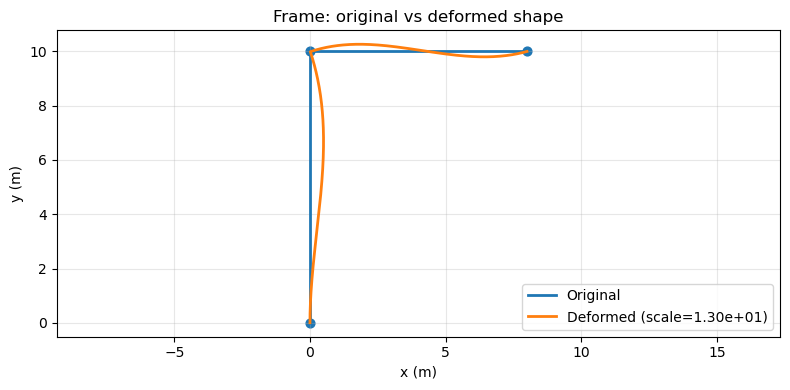

Max actual nodal/curve displacement magnitude ≈ 3.832728e-02 m
Scale factor used = 1.304554e+01


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Node coordinates (m)
# -----------------------------
nodes = {
    1: np.array([0.0, 0.0]),
    2: np.array([0.0, 10.0]),
    3: np.array([8.0, 10.0]),
}

# Global DOFs: [u1x,u1y,th1,u2x,u2y,th2,u3x,u3y,th3]
u = np.array([
    0.0, 0.0, 0.0,
    0.00095515, -0.00059949, 0.02539097,
    0.0, 0.0, 0.02120070
])

# Elements: (i, j)
elements = [(1,2), (2,3)]

def R_from_angle(c, s):
    # global -> local
    return np.array([[c, s],
                     [-s, c]])

def invR_from_angle(c, s):
    # local -> global (inverse rotation)
    return np.array([[c, -s],
                     [s,  c]])

def hermite_transverse(xi, L, v1, th1, v2, th2):
    s = xi / L
    N1 = 1 - 3*s**2 + 2*s**3
    N2 = L*(s - 2*s**2 + s**3)
    N3 = 3*s**2 - 2*s**3
    N4 = L*(-s**2 + s**3)
    return N1*v1 + N2*th1 + N3*v2 + N4*th2

def linear_axial(xi, L, u1, u2):
    s = xi / L
    return (1-s)*u1 + s*u2

# Build deformed polyline
XY0 = []
XYd = []

# sample points
npts = 200

all_pts0 = []
all_ptsd = []

for (i,j) in elements:
    Pi = nodes[i]
    Pj = nodes[j]
    d = Pj - Pi
    L = np.linalg.norm(d)
    c = d[0]/L
    s = d[1]/L

    # DOFs at node i and j
    def dof_indices(n):
        return [3*n-3, 3*n-2, 3*n-1]  # 0-based indices for ux,uy,th

    ii = dof_indices(i)
    jj = dof_indices(j)

    ui_g = u[ii[0]]; vi_g = u[ii[1]]; thi = u[ii[2]]
    uj_g = u[jj[0]]; vj_g = u[jj[1]]; thj = u[jj[2]]

    # transform global translations to local [u,v]
    R = R_from_angle(c,s)
    ti_local = R @ np.array([ui_g, vi_g])
    tj_local = R @ np.array([uj_g, vj_g])

    u1l, v1l = ti_local
    u2l, v2l = tj_local

    xi = np.linspace(0, L, npts)
    u_ax = linear_axial(xi, L, u1l, u2l)
    v_tr = hermite_transverse(xi, L, v1l, thi, v2l, thj)

    # local -> global displacement at each xi
    invR = invR_from_angle(c,s)
    disp_g = np.vstack([invR @ np.array([u_ax[k], v_tr[k]]) for k in range(npts)])

    # original points
    pts0 = np.vstack([Pi + (xi[k]/L)*d for k in range(npts)])
    ptsd = pts0 + disp_g

    all_pts0.append(pts0)
    all_ptsd.append(ptsd)

# concatenate (avoid duplicating shared node)
P0 = np.vstack([all_pts0[0], all_pts0[1][1:]])
Pd = np.vstack([all_ptsd[0], all_ptsd[1][1:]])

# auto scale for visualization
max_disp = np.max(np.linalg.norm(Pd - P0, axis=1))
scale = 1.0 if max_disp == 0 else 0.5 / max_disp  # target ~0.5 m visual

plt.figure(figsize=(8,4))
plt.plot(P0[:,0], P0[:,1], linewidth=2, label="Original")
plt.plot(P0[:,0] + scale*(Pd[:,0]-P0[:,0]),
         P0[:,1] + scale*(Pd[:,1]-P0[:,1]),
         linewidth=2, label=f"Deformed (scale={scale:.2e})")

plt.scatter([nodes[k][0] for k in nodes], [nodes[k][1] for k in nodes], s=40)
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Frame: original vs deformed shape")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Max actual nodal/curve displacement magnitude ≈ {max_disp:.6e} m")
print(f"Scale factor used = {scale:.6e}")

# Reflection (Required)

In 3–6 sentences:

- What part felt easiest? Describe in speciics

  None.
- What part felt hardest? Describe in speciics

  Must be the partition. The matrix dimensions are too large, making it prone to errors.
- One bug you encountered and how you fixed it.

  Helped another classmate identify a calculation error caused by differing units. I consistently used kN and m as units and did not encounter any errors.
- One thing you still don’t understand.

  None
- If you used collaboration or AI tools, briefly describe how.

  I used ChatGPT to convert the manuscript for the first question into Markdown code, and also for some of the matrices in the second question.
  Both two images were also created using ChatGPT.